# 03 — Calibration & regularization (OLS / Ridge / Lasso / ElasticNet / Huber)

We study stability under noise/outliers and compare standard LS regression vs regularization and robust regression.

## Correspondence with the paper
- Regularization: Ridge/Lasso/ElasticNet
- Robust regression: Huber
- Statistical limits: sensitivity to noise/outliers

## Outputs
- Comparison table (MAE/RMSE)
- Error distribution: OLS vs Huber

In [1]:
import sys
import os

# Add project root to Python path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root added:", project_root)

Project root added: c:\Users\rayzu\Pictures\fx-option-pricing-ml


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from src.bs_fx import garman_kohlhagen_price
from src.calibration import compare_models, make_models

rng = np.random.default_rng(0)
n = 25_000

S = rng.uniform(0.8, 1.4, n)
K = rng.uniform(0.8, 1.4, n)
T = rng.uniform(0.05, 2.0, n)
rd = rng.uniform(0.0, 0.06, n)
rf = rng.uniform(0.0, 0.06, n)
sigma = rng.uniform(0.05, 0.50, n)

y_clean = garman_kohlhagen_price(S, K, T, rd, rf, sigma, option="call")

# Gaussian noise
y_noisy = y_clean + rng.normal(0, 0.01, n)

# Outliers (1%)
out_idx = rng.choice(np.arange(n), size=int(0.01*n), replace=False)
y_noisy[out_idx] += rng.normal(0, 0.20, size=len(out_idx))

X = pd.DataFrame({"S": S, "K": K, "T": T, "rd": rd, "rf": rf, "sigma": sigma})
y = pd.Series(y_noisy, name="call_price")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
table = compare_models(X_train, y_train, X_test, y_test, ridge_alpha=1.0, lasso_alpha=1e-3, enet_alpha=1e-3, enet_l1_ratio=0.5)
table
table.to_csv("../results/calibration_comparison.csv", index=False)

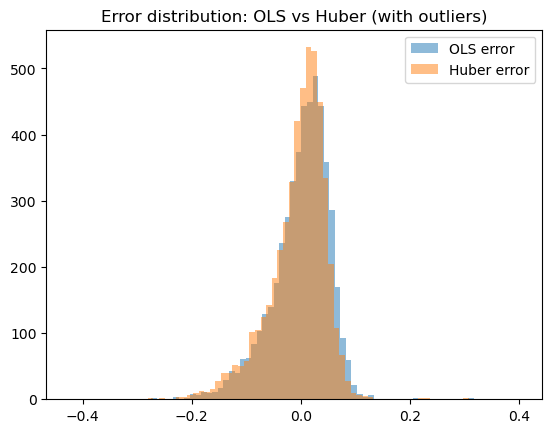

In [7]:
models = make_models()
ols = models["OLS"].fit(X_train, y_train)
huber = models["Huber"].fit(X_train, y_train)

err_ols = ols.predict(X_test) - y_test
err_huber = huber.predict(X_test) - y_test

plt.figure()
plt.hist(err_ols, bins=80, alpha=0.5, label="OLS error")
plt.hist(err_huber, bins=80, alpha=0.5, label="Huber error")
plt.legend()
plt.title("Error distribution: OLS vs Huber (with outliers)")
plt.savefig("../results/figures/calibration_error_distribution.png", dpi=300)
plt.show()

# Discussion

Regularization improves stability in the presence of noise and outliers.

## Observations

- OLS is highly sensitive to outliers.
- Ridge stabilizes coefficients.
- Lasso performs feature shrinkage.
- Huber regression is robust to extreme deviations.

## Statistical meaning

Bias-variance tradeoff becomes critical in noisy financial environments.

## Practical implication

Robust regression techniques are better suited for real-world option calibration where
market quotes may contain microstructure noise.

This connects directly to the statistical limitations discussed in the paper.
## Reproducibility

All experiments were performed with:
- Random seed fixed
- Deterministic splits
- Explicit parameter ranges

This ensures full reproducibility of the results.